In [28]:
# Importing
import os
import h5py
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import xdf
import psyphyea
import glob
import csv
import math
import warnings
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint,EarlyStopping
plt.style.use('fivethirtyeight')
warnings.filterwarnings("ignore")

In [29]:
def get_file_path(sub_id):
    file_dir = '/mnt/neurodata/NeurofeedbackStudy/data/processed/0' + str(sub_id)   # Yields good result
    #file_dir = '/mnt/neurodata/NeurofeedbackStudy/data/processed/029'
    h5_filepaths = glob.glob(file_dir + '/*')
    print(*h5_filepaths,sep = '\n')
    filelist = []
    for i in range(len(h5_filepaths)):
        if h5_filepaths[i].find('SHL.') != -1 or h5_filepaths[i].find('SLH.') != -1:
            filelist.append(i)
    temp = [0 ] * 6

    for i in filelist:
        st = h5_filepaths[i]
        indx = int(st[st.rfind('/') + 5:st.find('.') - 3])
        temp[indx-1] = int(i)

    filelist = temp

    print (filelist)

    return h5_filepaths,filelist
# MLP classifier function
def MLP(x_train, x_test, y_train, y_test,verbose = False):
    scaler = StandardScaler()
    # Fit only to the training data
    #scaler.fit(x_train)
    # Now apply the transformations to the data:
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    print("Number of training samples:",len(x_train))
    print("Number of testing samples:",len(x_test))
    mlp = MLPClassifier(hidden_layer_sizes=(100,10,10,10), activation = 'relu',solver='adam',learning_rate='adaptive', max_iter=100)
    #mlp = MLPClassifier()
    mlp.fit(x_train,y_train)
    predictions = mlp.predict(x_train)
    if verbose:
        print('Accuracy report for training')
        print('confusion matrix')
        print(confusion_matrix(y_train,predictions))
        print('classification report')
        print(classification_report(y_train,predictions))
    predictions = mlp.predict(x_test)
    if verbose:
        print('Accuracy report for testing')
        print('confusion matrix')
        print(confusion_matrix(y_test,predictions))
        print('classification report')
        print(classification_report(y_test,predictions))
    
    # Finding overall accuracy
    l = len(y_test)
    acc = np.arange(l)[predictions == y_test]
    avg_acc = (len(acc)*100)/l
    print('Overall accuracy = {}%'.format(avg_acc))
          
    return predictions,avg_acc

## SVM classifier function
def SVM(x_train, x_test, y_train, y_test,verbose = False):
    scaler = StandardScaler()
    # Fit only to the training data
    #scaler.fit(x_train)
    # Now apply the transformations to the data:
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    print("Number of training samples:",len(x_train))
    print("Number of testing samples:",len(x_test))
    svmc = SVC()
    #mlp = MLPClassifier()
    svmc.fit(x_train,y_train)
    predictions = svmc.predict(x_train)
    if verbose:
        print('Accuracy report for training')
        print('confusion matrix')
        print(confusion_matrix(y_train,predictions))
        print('classification report')
        print(classification_report(y_train,predictions))
    predictions = svmc.predict(x_test)
    if verbose:
        print('Accuracy report for testing')
        print('confusion matrix')
        print(confusion_matrix(y_test,predictions))
        print('classification report')
        print(classification_report(y_test,predictions))
    
    # Finding overall accuracy
    l = len(y_test)
    acc = np.arange(l)[predictions == y_test]
    avg_acc = (len(acc)*100)/l
    print('Overall accuracy = {}%'.format(avg_acc))
          
    return predictions,avg_acc

## Pulling out gun velocity data
def load_data(sub_id,ch_name,session_index,verbose = False):
    """Function for loading data from h5 file"""

    filename = 'data'+ str(sub_id) +'.h5'

    fo = h5py.File(filename,'r')
    def func(y,x):print('Name: %40s Attrs: %d'%(x.name,len(x.attrs)))
    if verbose:
        fo.visititems(func)
    x = np.array(fo[str(ch_name) + '/Session_' + str(session_index) + '/data'])
    label = np.array(fo['Gun_velocity/Session_' + str(session_index) + '/stress'])
    fo.close()
    print('Data load successful')
    return x,label

def extract(x):
    x = np.array(x)
    data = np.zeros((len(x),8))
    for index,i in enumerate(x):
        i = np.array(i) # Converting in numpy array
        m = np.mean(i) # Taking mean
        std = np.std(i) # Taking standard deviation
        mx = np.max(i) # Taking max value
        mn = np.min(i)
        power = get_power(i)
        
        ## Finding the fft of signal
        f = np.fft.fft(i)
        ## Checking and splitting into two parts
        if len(f) % 2 == 0:
            l,h = np.split(f,2)
        else:
            l,h = np.split(f[:-1],2) # Omitting the last element to make in even number
        ## Finding the absolute value
        low_abs = np.sum(np.abs(l))
        high_abs = np.sum(np.abs(h))
        
        data[index,0] = m
        data[index,1] = std
        data[index,2] = mx
        data[index,3] = power
        data[index,4] = mn
        data[index,5] = mx * mn
        data[index,6] = low_abs
        data[index,7] = high_abs
        
    return data
def get_power(a):
    energy = np.sum(np.square(a))
    power = energy/len(a)
    return power

def pick_session_data(features,sub_id,session_index):
    fo = h5py.File('data' + str(sub_id) +'.h5','r') # change here
    def func(y,x):print('Name: %40s Attrs: %d'%(x.name,len(x.attrs)))
    
    #features = ['Gun_velocity','EmpaticaAcceleration']
    #features = ['Gun_velocity','EmpaticaBVP','EmpaticaHR','EmpaticaAcceleration','EmpaticaGSR']#,'EmpaticaBVP','Gun_velocity','EmpaticaAcceleration']
    #features = ['EmpaticaBVP','EmpaticaHR','EmpaticaGSR']
    
    label = np.array(fo['Gun_velocity/Session_' + str(session_index) + '/stress'])
    data_len = len(label)
    #for file_select in filelist:
    data_ext = np.empty((data_len,0))
    for ch_name in features:
        data = np.array(fo[str(ch_name) + '/Session_' + str(session_index) + '/data'])

        if ch_name == 'EmpaticaAcceleration':
            temp_1 = extract(data[:,0])
            temp_2 = extract(data[:,1])
            temp_3 = extract(data[:,2])
            data_temp = np.concatenate((temp_1,temp_2,temp_3),axis = 1)        

        else:
            temp_1 = extract(data)
            data_temp = np.array(temp_1)
            
        #data_ext = np.hstack((data_ext,data_temp))
        data_ext = np.concatenate([data_ext, data_temp],axis = 1)

    fo.close()

    return data_ext,label

## Best run (MLP)

In [4]:
## MLP
tic = time.time()
features = ['EmpaticaHR','EmpaticaBVP','EmpaticaAcceleration','EmpaticaGSR']

x1,y1 = pick_session_data(features,21,1)
x2,y2 = pick_session_data(features,21,2)
x3,y3 = pick_session_data(features,21,3)
x4,y4= pick_session_data(features,21,4)
x5,y5= pick_session_data(features,21,5)
x6,y6 = pick_session_data(features,21,6)

data = np.concatenate((x1,x2,x3,x4,x5,x6),axis = 0)
label = np.concatenate((y1,y2,y3,y4,y5,y6),axis = 0)

x_train, x_test, y_train, y_test = train_test_split(data,label,test_size = 720)
_,acc = MLP(x_train, x_test, y_train, y_test,verbose = True)

toc = time.time()
exec_time = toc - tic
exec_time

Number of training samples: 2520
Number of testing samples: 720
Accuracy report for training
confusion matrix
[[1241   12]
 [   7 1260]]
classification report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1253
           1       0.99      0.99      0.99      1267

   micro avg       0.99      0.99      0.99      2520
   macro avg       0.99      0.99      0.99      2520
weighted avg       0.99      0.99      0.99      2520

Accuracy report for testing
confusion matrix
[[335  32]
 [ 30 323]]
classification report
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       367
           1       0.91      0.92      0.91       353

   micro avg       0.91      0.91      0.91       720
   macro avg       0.91      0.91      0.91       720
weighted avg       0.91      0.91      0.91       720

Overall accuracy = 91.38888888888889%


3.947455644607544

## Comparing MLP,LR and SVM

In [5]:
## Finding the overall accuracy for all subjects data (MLP)
subjects = [21,28,29,31]
features = ['Gun_velocity','EmpaticaHR','EmpaticaBVP','EmpaticaAcceleration','EmpaticaGSR']
exec_time_mlp = []
accuracy_mlp = []

for s in subjects:
    
    tic = time.time()
    x1,y1 = pick_session_data(features,s,1)
    x2,y2 = pick_session_data(features,s,2)
    x3,y3 = pick_session_data(features,s,3)
    x4,y4= pick_session_data(features,s,4)
    x5,y5= pick_session_data(features,s,5)
    x6,y6 = pick_session_data(features,s,6)

    data = np.concatenate((x1,x2,x3,x4,x5,x6),axis = 0)
    label = np.concatenate((y1,y2,y3,y4,y5,y6),axis = 0)

    x_train, x_test, y_train, y_test = train_test_split(data,label,test_size = 720)
    _,acc = MLP(x_train, x_test, y_train, y_test)

    toc = time.time()
    exec_time_mlp.append(toc - tic)
    accuracy_mlp.append(acc)

Number of training samples: 2520
Number of testing samples: 720
Overall accuracy = 88.88888888888889%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 90.0%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 91.38888888888889%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 90.69444444444444%


In [46]:
## Finding the overall accuracy for all subjects data (LR)
subjects = [21,28,29,31]
features = ['Gun_velocity','EmpaticaHR','EmpaticaBVP','EmpaticaAcceleration','EmpaticaGSR']
exec_time_lr = []
accuracy_lr = []

for s in subjects:
    
    tic = time.time()
    x1,y1 = pick_session_data(features,s,1)
    x2,y2 = pick_session_data(features,s,2)
    x3,y3 = pick_session_data(features,s,3)
    x4,y4= pick_session_data(features,s,4)
    x5,y5= pick_session_data(features,s,5)
    x6,y6 = pick_session_data(features,s,6)

    data = np.concatenate((x1,x2,x3,x4,x5,x6),axis = 0)
    label = np.concatenate((y1,y2,y3,y4,y5,y6),axis = 0)


    x_train, x_test, y_train, y_test = train_test_split(data,label,test_size = 720)
    row,col = x_train.shape
    model = Sequential() 
    model.add(Dense(1, input_dim=col, activation='relu'))
    nb_epoch = 15

    callbacks = [EarlyStopping(monitor='val_loss', patience=0,verbose = 1)]
    model.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=['accuracy'])
    print(model.summary())
    history = model.fit(x_train, y_train, batch_size=64, epochs=nb_epoch,verbose=1, validation_data=(x_test, y_test),callbacks = callbacks) 
    score = model.evaluate(x_test, y_test, verbose=1,batch_size = 2048) 
    print('Test score:', score[0]) 
    print('Test accuracy:', score[1]*100)
    
    toc = time.time()
    exec_time_lr.append(toc - tic)
    accuracy_lr.append(score[1]*100)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_13 (Dense)             (None, 1)                 57        
Total params: 57
Trainable params: 57
Non-trainable params: 0
_________________________________________________________________
None
Train on 2520 samples, validate on 720 samples
Epoch 1/15
2520/2520 [==============================] - 0s 87us/step - loss: 15810937.2603 - acc: 0.0028 - val_loss: 9907779.3778 - val_acc: 0.0042
Epoch 2/15
2520/2520 [==============================] - 0s 17us/step - loss: 7082808.5738 - acc: 0.0107 - val_loss: 3894118.2278 - val_acc: 0.0250
Epoch 3/15
2520/2520 [==============================] - 0s 16us/step - loss: 2521454.5683 - acc: 0.0587 - val_loss: 1025874.7014 - val_acc: 0.1264
Epoch 4/15
2520/2520 [==============================] - 0s 19us/step - loss: 633870.4280 - acc: 0.2222 - val_loss: 172833.4356 - val_acc: 0.3347
Epoch 5/15
2520/2520 [=============

In [30]:
## Finding the overall accuracy for all subjects data (SVM)
subjects = [21,28,29,31]
features = ['Gun_velocity','EmpaticaHR','EmpaticaBVP','EmpaticaAcceleration','EmpaticaGSR']
exec_time_svm = []
accuracy_svm = []

for s in subjects:
    
    tic = time.time()
    x1,y1 = pick_session_data(features,s,1)
    x2,y2 = pick_session_data(features,s,2)
    x3,y3 = pick_session_data(features,s,3)
    x4,y4= pick_session_data(features,s,4)
    x5,y5= pick_session_data(features,s,5)
    x6,y6 = pick_session_data(features,s,6)

    data = np.concatenate((x1,x2,x3,x4,x5,x6),axis = 0)
    label = np.concatenate((y1,y2,y3,y4,y5,y6),axis = 0)

    x_train, x_test, y_train, y_test = train_test_split(data,label,test_size = 720)
    _,acc = SVM(x_train, x_test, y_train, y_test)

    toc = time.time()
    exec_time_svm.append(toc - tic)
    accuracy_svm.append(acc)

Number of training samples: 2520
Number of testing samples: 720
Overall accuracy = 78.47222222222223%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 87.91666666666667%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 88.88888888888889%
Number of training samples: 3600
Number of testing samples: 720
Overall accuracy = 90.41666666666667%


## Plotting the performance of MLP,LR and SVM

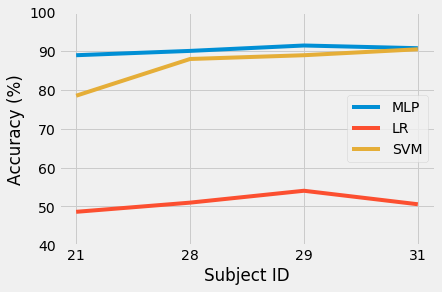

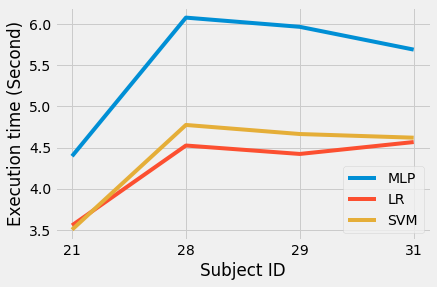

In [59]:
x_pos = np.arange(4)
plt.figure()
plt.plot(x_pos,accuracy_mlp, label = 'MLP')
plt.plot(x_pos,accuracy_lr, label = 'LR')
plt.plot(x_pos,accuracy_svm, label = 'SVM')
plt.xlabel('Subject ID');plt.ylabel('Accuracy (%)');plt.xticks(x_pos,subjects);plt.ylim([40,100])
plt.legend()
plt.figure()
plt.plot(x_pos,exec_time_mlp, label = 'MLP')
plt.plot(x_pos,exec_time_lr, label = 'LR')
plt.plot(x_pos,exec_time_svm, label = 'SVM')
plt.xlabel('Subject ID');plt.ylabel('Execution time (Second)');plt.xticks(x_pos,subjects)
plt.legend()

## Applying Manifold learning here

In [42]:
data = np.concatenate((x1,x2),axis = 0)
label = np.concatenate((y1,y2),axis = 0)

In [59]:
from sklearn.manifold import MDS
tic = time.time()
embedding = MDS(n_components=20)
x_t = embedding.fit_transform(data)
toc = time.time()
exec_time = toc - tic
exec_time

30.430464506149292

In [62]:
tic = time.time()
x_train, x_test, y_train, y_test = train_test_split(x_t,label,test_size = 250)
_,acc = MLP(x_train, x_test, y_train, y_test)
toc = time.time()
exec_time = toc - tic
exec_time

Number of training samples: 1010
Number of testing samples: 250
Overall accuracy = 79.6%


0.6202540397644043

## Comparsion of MDS and Classical machine learning approach

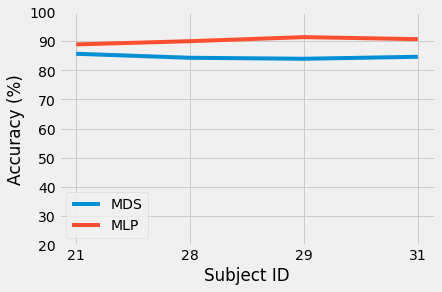

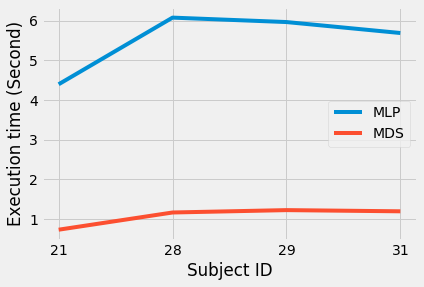

In [72]:
accuracy_mds = [85.68,84.31,83.97,84.65] ## Data found from table
exec_time_mds = [0.726,1.16,1.22,1.19]
plt.plot(x_pos,accuracy_mds,label = 'MDS')
plt.plot(x_pos,accuracy_mlp,label = 'MLP')
plt.xlabel('Subject ID');plt.ylabel('Accuracy (%)');plt.xticks(x_pos,subjects);plt.ylim([20,100])
plt.legend()
plt.figure()
plt.plot(x_pos,exec_time_mlp, label = 'MLP')
plt.plot(x_pos,exec_time_mds, label = 'MDS')
plt.xlabel('Subject ID');plt.ylabel('Execution time (Second)');plt.xticks(x_pos,subjects)
plt.legend()